In [ ]:
from arxivML import utils_ml 
from arxivML import utils_word 
import gc

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from matplotlib.ticker import MaxNLocator, FuncFormatter

### Get Word Co-Occurances

In [2]:
ngram_abstracts = np.load("saved_files/ngram_abstracts.npy", mmap_mode="r")
filtered_concept_arr = np.unique(np.load("saved_files/overlapping_filtered_5_concepts.npy"))
year_arr = np.load("saved_files/year_arr.npy", mmap_mode="r")
month_arr = np.load("saved_files/month_arr.npy", mmap_mode="r")

print("Concepts which were tracked",filtered_concept_arr.shape)
print("Abstracts",ngram_abstracts.shape)
print("Year associated to abstract",year_arr.shape)


Concepts which were tracked (10235,)
Abstracts (66839,)
Year associated to abstract (66839,)


In [3]:
unique_years = np.unique(year_arr)
unique_months = np.unique(month_arr)
year_month_arr = [(y, m) for y in unique_years for m in unique_months]

In [4]:
def update_co_occurrences(word_year_list, word_co_occurrences):
    word_list, year = word_year_list
    for word in word_list:
        # Ensure word has an entry in the dictionary
        if word not in word_co_occurrences:
            word_co_occurrences[word] = {}
        
        for other_word in word_list:
            if other_word != word:
                # Add year to the list of years for co-occurrence without overwriting
                if other_word not in word_co_occurrences[word]:
                    word_co_occurrences[word][other_word] = []
                word_co_occurrences[word][other_word].append(year)


def keep_words_with_underscore(input_string):
    # Matches words with underscores
    pattern = r'\b\w*_[\w_]*\b'
    return re.findall(pattern, input_string)

def get_word_co_occurrences(filtered_concept_arr, ngram_abstracts, year_arr, month_arr):
    phys_concept_dict = {k: 1 for k in filtered_concept_arr}
    ocurr_arr = []
    
    for abstract, year, month in zip(ngram_abstracts, year_arr, month_arr):
        matching_words = keep_words_with_underscore(abstract)
        temp = [word for word in matching_words if word in phys_concept_dict]
        if len(temp) > 1:
            ocurr_arr.append([temp, year])

    word_co_occurrences = {}
    for word_list in tqdm(ocurr_arr):
        update_co_occurrences(word_list, word_co_occurrences)
    
    return word_co_occurrences

In [5]:
word_co_occurrences = get_word_co_occurrences(filtered_concept_arr, ngram_abstracts, year_arr, month_arr)

100%|██████████| 63091/63091 [00:03<00:00, 18311.83it/s]


### Get Embedding

In [ ]:
def load_model_for_year(year, month, k, embed, deltaT):
    """Load a Word2Vec model for a specific year based on the given type."""
    
    model_paths = f"saved_w2v_models/extend_model_{k}_{embed}_{deltaT}_{year*12 + month}.model"
    
    
    return utils_word.Word2Vec.load(model_paths)
    
def get_method_embeddings(filtered_concept_arr, year_arr, k ,embed, deltaT):
    """Get method embeddings, either by loading from files or processing the data."""
    
    
    # Initialize dictionaries and counters
    c_dict = {}
    phys_concept_dict = {k: 1 for k in filtered_concept_arr}
    cnt_0, cnt_1 = 0, 0

    # Get unique years
    unique_years = np.unique(year_arr)

    

    for cnt, inx in enumerate(range(0, len(year_month_arr), deltaT)):
        low_inx = year_month_arr[inx]
        
        high_index = inx + deltaT - 1
        if high_index < len(year_month_arr):
            high_inx = year_month_arr[high_index]
        else:
            # Handle the last, potentially incomplete interval
            high_inx = year_month_arr[-1]

        start_year, start_month = low_inx
        end_year, end_month = high_inx
    
        if end_month == 12:
           
            loaded_w2v = load_model_for_year(start_year, start_month, k, embed, deltaT)
            for c in phys_concept_dict:
                if c not in c_dict:
                    c_dict[c] = {}
                if start_year in c_dict[c]:
                    continue
                try:
                    vec_enc = loaded_w2v.wv[c]
                    c_dict[c][start_year] = vec_enc
                    cnt_0 += 1
                except KeyError:
                    cnt_1 += 1

    # print(f"Found {cnt_0} vectors, missed {cnt_1} vectors.")

    # Fill missing years
    concept_inx_arr = []
    for c in phys_concept_dict:
        if c_dict[c]:
            concept_inx_arr.append(c)
            success_years = sorted(c_dict[c].keys())
            first_success_year = success_years[0]
            for start_year in unique_years:
                if start_year < first_success_year:
                    c_dict[c][start_year] = c_dict[c][first_success_year]
                else:
                    break

    concept_inx_arr = np.array(concept_inx_arr)

    # Prepare the encoding array
    num_concepts = len(concept_inx_arr)
    num_years = len(unique_years)

    c_encoding_arr = np.zeros((num_concepts, num_years, embed))
    c_inx_arr = []

    for cnt, concept in enumerate(concept_inx_arr):
        year_vectors = c_dict[concept]
        c_encoding_arr[cnt] = np.array([year_vectors.get(year, np.zeros(embed)) for year in unique_years])
        c_inx_arr.append(concept)

    c_inx_arr = np.array(c_inx_arr)

    
    gc.collect()


    return c_inx_arr, c_encoding_arr


### Create Dataset

In [ ]:
def create_dataset_indexing(data: np.ndarray, word_co_occurrences: dict, year_arr: np.ndarray, c_inx_arr: np.ndarray, 
                 input_window_size: int = 5, output_window_size: int = 3, offset_to_current_year: int = 1, print_test: bool = False, save=True):
    """
    Dataset indexing for time series data.

    Args:
        data (np.ndarray): The input data.
        word_co_occurrences (dict): Dictionary of word co-occurrences.
        year_arr (np.ndarray): Array of years.
        c_inx_arr (np.ndarray): Array of concept indices.
        input_window_size (int, optional): Size of the input window. Defaults to 5.
        output_window_size (int, optional): Size of the output window. Defaults to 3.
        offset_to_current_year (int, optional): Offset to the current year. Defaults to 1.
        print_test (bool, optional): Whether to print test information. Defaults to False.

    Returns:
        np.ndarray: Positive index pair array.
        np.ndarray: Negative index pair array.
    """
    train_window_data = data[:, -input_window_size-output_window_size-offset_to_current_year:-output_window_size-offset_to_current_year]
    label_year_range = (year_arr[-output_window_size:] if offset_to_current_year == 0 
                                else year_arr[-output_window_size-offset_to_current_year:-offset_to_current_year])

    co_occur_concept_pair_arr = utils_word.get_co_occur_concept_pair_after_year_arr(
        word_co_occurrences, label_year_range[0], label_year_range[-1])
    
    print(f"Training Window: {utils_word.get_years_range(year_arr,-input_window_size-output_window_size-offset_to_current_year, -output_window_size-offset_to_current_year)}")
    print(f"Label Window: {utils_word.get_years_range(year_arr,-output_window_size-offset_to_current_year, -offset_to_current_year)}")



    # Precompute indices for each unique concept in c_inx_arr
    concept_to_indices = {concept: np.where(c_inx_arr == concept)[0] for concept in np.unique(c_inx_arr)}

    # Convert word_co_occurrences to a dictionary of sets for fast membership checking
    word_co_occurrences_set = {k: set(v) for k, v in word_co_occurrences.items()}

    pos_inx_pair_arr = np.zeros((len(co_occur_concept_pair_arr),2), dtype=int)
    
    for inx, pair in enumerate(co_occur_concept_pair_arr):
        pos_inx_pair_arr[inx, 0] = concept_to_indices[pair[0]][0]
        pos_inx_pair_arr[inx, 1] = concept_to_indices[pair[1]][0]

    print("Finished Positives")

    neg_inx_pair_arr = np.zeros((len(co_occur_concept_pair_arr), 2), dtype=int)
    checked_pairs = set()
    neg_inx = 0

    while neg_inx < len(pos_inx_pair_arr):
        sampled_pair = tuple(np.random.choice(train_window_data.shape[0], size=2, replace=False))
        
        # Ensure the sampled pair is not the same and hasn't been checked before
        if sampled_pair not in checked_pairs:
            checked_pairs.add(sampled_pair)
            concept_0, concept_1 = c_inx_arr[sampled_pair[0]], c_inx_arr[sampled_pair[1]]

            if concept_1 not in word_co_occurrences_set.get(concept_0, set()):
                neg_inx_pair_arr[neg_inx, 0] = concept_to_indices[concept_0][0]
                neg_inx_pair_arr[neg_inx, 1] = concept_to_indices[concept_1][0]
                neg_inx += 1
    print("Finished Negatives")

    if print_test:
        save_pos_arr = [word_co_occurrences[c_inx_arr[pos_inx_pair_arr[_][0]]][c_inx_arr[pos_inx_pair_arr[_][1]]] for _ in range(len(pos_inx_pair_arr))]
        save_neg_arr = [c_inx_arr[neg_inx_pair_arr[_][1]] in word_co_occurrences[c_inx_arr[neg_inx_pair_arr[_][0]]] for _ in range(len(neg_inx_pair_arr))]

        save_pos_arr = [x for xs in save_pos_arr for x in xs]
        
        print("Positive: Expect to be years: ", np.unique(save_pos_arr))
        print("Negative: Expect to be 0: ", np.sum(save_neg_arr))

    return pos_inx_pair_arr, neg_inx_pair_arr

class CustomPairDataset(Dataset):
    def __init__(self, train_window_data, pair_arr, labels, input_window_size, output_window_size, offset_to_current_year):
        self.train_window_data = train_window_data[:, -input_window_size-output_window_size-offset_to_current_year:-output_window_size-offset_to_current_year]
        self.pair_arr = pair_arr
        self.labels = labels
        self.shape = self.train_window_data.shape

    def __len__(self):
        return len(self.pair_arr)

    def __getitem__(self, idx):
        inx_0, inx_1 = self.pair_arr[idx]
        label = self.labels[idx]
        enc_0 = self.train_window_data[inx_0]
        enc_1 = self.train_window_data[inx_1]
        enc_01 = np.concatenate((enc_0, enc_1), axis=-1)
        return torch.from_numpy(enc_01), torch.tensor([label], dtype=torch.float32), inx_0, inx_1 

def create_train_val_datasets(train_window_data, pos_inx_pair_arr, neg_inx_pair_arr, input_window_size, output_window_size, offset_to_current_year, test_size=0.2, random_state=42):
    # Create labels
    pos_labels = np.ones(len(pos_inx_pair_arr))
    neg_labels = np.zeros(len(neg_inx_pair_arr))
    
    # Concatenate positive and negative pairs and labels
    all_pairs = np.vstack((pos_inx_pair_arr, neg_inx_pair_arr))
    all_labels = np.concatenate((pos_labels, neg_labels))
    
    # Split indices into training and test sets
    train_idx, test_idx = train_test_split(
        np.arange(len(all_pairs)), test_size=test_size, random_state=random_state, stratify=all_labels
    )
    
    # Create training and test datasets
    train_dataset = CustomPairDataset(train_window_data, all_pairs[train_idx], all_labels[train_idx], input_window_size, output_window_size, offset_to_current_year)
    test_dataset = CustomPairDataset(train_window_data, all_pairs[test_idx], all_labels[test_idx], input_window_size, output_window_size, offset_to_current_year)
    
    return train_dataset, test_dataset


def create_fold_datasets(train_window_data, fold_inx,  pos_inx_pair_arr, neg_inx_pair_arr, input_window_size, output_window_size, offset_to_current_year):
    # Create labels
    pos_labels = np.ones(len(pos_inx_pair_arr))
    neg_labels = np.zeros(len(neg_inx_pair_arr))
    
    # Concatenate positive and negative pairs and labels
    all_pairs = np.vstack((pos_inx_pair_arr, neg_inx_pair_arr))
    all_labels = np.concatenate((pos_labels, neg_labels))
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx, val_idx) in enumerate(kfold.split(np.arange(len(all_labels)), all_labels)):
        if fold == fold_inx:
            train_dataset = CustomPairDataset(train_window_data, all_pairs[train_idx], all_labels[train_idx], input_window_size, output_window_size, offset_to_current_year)
            test_dataset = CustomPairDataset(train_window_data, all_pairs[val_idx], all_labels[val_idx], input_window_size, output_window_size, offset_to_current_year)
    
    return train_dataset, test_dataset


def create_test_datasets(train_window_data, pos_inx_pair_arr, neg_inx_pair_arr, input_window_size, output_window_size, offset_to_current_year):
    # Create labels
    pos_labels = np.ones(len(pos_inx_pair_arr))
    neg_labels = np.zeros(len(neg_inx_pair_arr))
    
    # Concatenate positive and negative pairs and labels
    all_pairs = np.vstack((pos_inx_pair_arr, neg_inx_pair_arr))
    all_labels = np.concatenate((pos_labels, neg_labels))
     
    return CustomPairDataset(train_window_data, all_pairs, all_labels, input_window_size, output_window_size, offset_to_current_year)

In [ ]:
# Define the cross-validation function
def cross_validate(encoding_data, pos_inx, neg_inx, test_dataloader, num_epochs, patience, batch_size, k, embed, deltaT, input_dim, depth):
    
    fold_auc = []

    for fold in range(5):

        model = utils_ml.MlpDepth(input_dim, depth)

        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.005)
        scheduler = CosineAnnealingLR(optimizer,T_max=10)
       
        # Create data loaders for the current fold
        train_set, val_set = create_fold_datasets(train_window_data=encoding_data, fold_inx=fold, pos_inx_pair_arr=pos_inx, neg_inx_pair_arr=neg_inx, input_window_size=1, output_window_size=3, offset_to_current_year=3)
        
        train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
        val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

        # Train the model
        utils_ml.train_model(model, train_dataloader, val_dataloader, criterion, optimizer, scheduler,
                    num_epochs=num_epochs, patience=patience, file_name=f'saved_ml_models/best_model_fold_{k}_{embed}_{deltaT}_{fold}_{depth}.pth')

        # Validate the best model
        model.load_state_dict(torch.load(f'saved_ml_models/best_model_fold_{k}_{embed}_{deltaT}_{fold}_{depth}.pth'))
        fpr,tpr, roc_auc = utils_ml.compute_roc(model, test_dataloader, filename="method_final_v2")
        
        fold_auc.append((roc_auc))
       
    return fold_auc

In [ ]:
c = 0 
# Define parameter combinations for all cases
parameter_sets = []

parameter_sets.extend([(5, 512, 1, depth) for depth in [1,2,3,4,5,6]])

# Case 1: Iterate over k with fixed embed and deltaT
parameter_sets.extend([(k, 512, 1, 5) for k in [2,5,10,15]])

# Case 2: Iterate over embed with fixed k and deltaT
parameter_sets.extend([(5, embed, 1, 5) for embed in [32, 64, 128, 256, 512]])

# Case 3: Iterate over deltaT with fixed k and embed
parameter_sets.extend([(5, 512, deltaT, 5) for deltaT in [1, 6, 12]])

# parameter_sets.extend([(5,128,1,3)])


# Unified loop
for k, embed, deltaT, depth in tqdm(parameter_sets, desc="Processing parameter combinations"):
    # Extensive code block goes here
    print(f"Running with k={k}, embed={embed}, deltaT={deltaT}")
    
    c_inx_arr, c_encoding_arr = get_method_embeddings(filtered_concept_arr, year_arr, k ,embed, deltaT)

    seq_length = 1
    out_length = 3
    batch_size = 128

    
    scaler = StandardScaler()
    reshaped_data = c_encoding_arr.reshape(-1, c_encoding_arr.shape[-1])  
    normalized_data = scaler.fit_transform(reshaped_data)
    encoding_data = normalized_data.reshape(c_encoding_arr.shape)

    if c == 0:
        train_pos_inx_pair_arr_5_3_3, train_neg_inx_pair_arr_5_3_3 = create_dataset_indexing(data=encoding_data, word_co_occurrences=word_co_occurrences, year_arr = np.unique(year_arr), 
                                    c_inx_arr=c_inx_arr, input_window_size = seq_length, output_window_size = out_length, offset_to_current_year = 3, print_test=True)

        train_pos_inx_pair_arr_5_3_0, train_neg_inx_pair_arr_5_3_0 = create_dataset_indexing(data=encoding_data, word_co_occurrences=word_co_occurrences, year_arr = np.unique(year_arr), 
                                    c_inx_arr=c_inx_arr, input_window_size = seq_length, output_window_size = out_length, offset_to_current_year = 0, print_test=True)
    c += 1
    
    test_dataset = create_test_datasets(
        train_window_data=encoding_data, pos_inx_pair_arr=train_pos_inx_pair_arr_5_3_0, neg_inx_pair_arr=train_neg_inx_pair_arr_5_3_0, 
        input_window_size=seq_length, output_window_size=out_length, offset_to_current_year = 0)
    

    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    # # Initialize logging
    # # logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

    # # Example usage
    input_dim = test_dataset.train_window_data.shape[1] * test_dataset.train_window_data.shape[2] * 2  

   
    # Perform cross-validation
    results = cross_validate(encoding_data=encoding_data, pos_inx=train_pos_inx_pair_arr_5_3_3, neg_inx=train_neg_inx_pair_arr_5_3_3, test_dataloader=test_dataloader,
                num_epochs=50, patience=7, batch_size=batch_size, k=k, embed=embed, deltaT=deltaT, input_dim=input_dim, depth=depth)
    
    np.save(f"auc_ext/auc_fold_{k}_{embed}_{deltaT}_{depth}", results)

In [30]:
plt.style.use('tableau-colorblind10')
def plot_style():
    font_size       = 12
    dpi             = 200

    params = {'figure.dpi': dpi,
              'savefig.dpi': dpi,
              'font.size': font_size,
              'font.family': "serif",
              'figure.titlesize': font_size,
              'legend.fontsize': font_size,
              'axes.labelsize': font_size,
              'axes.titlesize': font_size,
              'xtick.labelsize': font_size,
              'ytick.labelsize': font_size,
              'text.usetex': True,
             }

    plt.rcParams.update(params)
plot_style()

In [158]:
parameter_sets = []

k_values = [2,5,10,15]
embed_values = [32, 64, 128, 256, 512]
deltaT_values = [1, 6, 12]
depth_values = [1,2,3,4,5,6]

# Case 1: Iterate over k with fixed embed and deltaT
parameter_sets.extend([(k, 128, 1) for k in k_values])

# Case 2: Iterate over embed with fixed k and deltaT
parameter_sets.extend([(5, embed, 1) for embed in [32, 64, 128, 256, 512]])

# Case 3: Iterate over deltaT with fixed k and embed
parameter_sets.extend([(5, 128, deltaT) for deltaT in [1, 6, 12]])

# Unified loop
auc_data = {}
for k, embed, deltaT in tqdm(parameter_sets, desc="Processing parameter combinations"):
    auc_data[(k, embed, deltaT)] = np.round(np.mean(np.load(f"auc_ext/auc_fold_{k}_{embed}_{deltaT}.npy")), 4)

auc_data_std = {}
for k, embed, deltaT in tqdm(parameter_sets, desc="Processing parameter combinations"):
    auc_data_std[(k, embed, deltaT)] = np.std(np.load(f"auc_ext/auc_fold_{k}_{embed}_{deltaT}.npy"))


best_combination = max(auc_data, key=auc_data.get)
best_k = 5
best_embed = 128
best_deltaT = 1
best_d = 5 

# Plot 1: Vary k, fix embed and deltaT to their best values
auc_scores_k = [auc_data[(k, best_embed, best_deltaT)] for k in k_values]
auc_std_k = [auc_data_std[(k, best_embed, best_deltaT)] for k in k_values]
# Plot 2: Vary embed, fix k and deltaT to their best values
auc_scores_embed = [auc_data[(best_k, embed, best_deltaT)] for embed in embed_values]
auc_std_embed = [auc_data_std[(best_k, embed, best_deltaT)] for embed in embed_values]
# Plot 3: Vary deltaT, fix k and embed to their best values
auc_scores_deltaT = [auc_data[(best_k, best_embed, deltaT)] for deltaT in deltaT_values]
auc_std_deltaT = [auc_data_std[(best_k, best_embed, deltaT)] for deltaT in deltaT_values]

parameter_sets = []

# Case 1: Iterate over k with fixed embed and deltaT
parameter_sets.extend([(5, 128, 1, d) for d in depth_values])

# Unified loop
auc_data_d = {}
for k, embed, deltaT, d in tqdm(parameter_sets, desc="Processing parameter combinations"):
    auc_data_d[(k, embed, deltaT,d)] = np.round(np.mean(np.load(f"auc_ext/auc_fold_{k}_{embed}_{deltaT}_{d}.npy")), 4)

auc_data_std_d = {}
for k, embed, deltaT, d in tqdm(parameter_sets, desc="Processing parameter combinations"):
    auc_data_std_d[(k, embed, deltaT,d)] = np.std(np.load(f"auc_ext/auc_fold_{k}_{embed}_{deltaT}_{d}.npy"))


best_combination = max(auc_data, key=auc_data.get)
best_k = 5
best_embed = 128
best_deltaT = 1

auc_scores_d = [auc_data_d[(best_k, best_embed, best_deltaT, d)] for d in depth_values]
auc_std_d = [auc_data_std_d[(best_k, best_embed, best_deltaT, d)] for d in depth_values]

auc_scores_depth = [auc_data[(best_k, best_embed, best_deltaT, d)] for d in depth_values]
auc_std_depth = [auc_data_std[(best_k, best_embed, best_deltaT, d)] for d in depth_values]

/tmp/ipykernel_1344371/2049646538.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


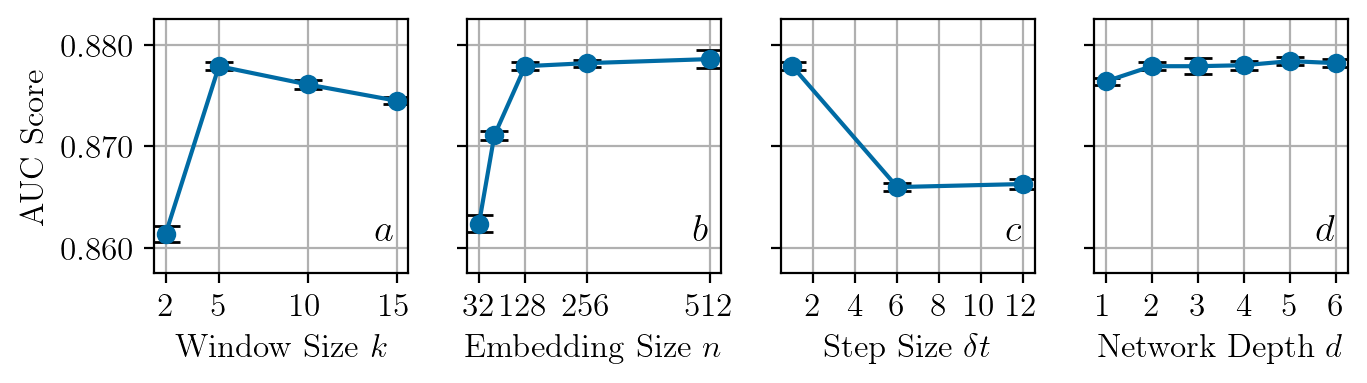

In [134]:
# Best values for labels (replace with actual best values)
best_k, best_embed, best_deltaT, best_d = 5, 128, 1, 5

# Create the consolidated figure
fig, axes = plt.subplots(1, 4, figsize=(7, 3), constrained_layout=True)

# Loop to ensure each subplot has the same size
for ax in axes:
    ax.set_box_aspect(1)  # Ensures square aspect ratio

# Plot 1: Embedding size
axes[0].errorbar(k_values, auc_scores_k, yerr=auc_std_k, marker='o', label=f"$n$={best_embed}, $\delta t$={best_deltaT}, $d$={best_d}", capsize=5,                  # Length of the error bar caps
    ecolor='black',             # Color of error bars and caps
    elinewidth=1)

axes[0].set_xticks(k_values)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}"))
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0].set_xlabel("Window Size $k$")
axes[0].set_ylabel("AUC Score")
axes[0].grid(True)
axes[0].set_xticks([2,5,10,15])

# Plot 1: Embedding size
axes[1].errorbar(embed_values, auc_scores_embed, yerr=auc_std_embed, marker='o', label=f"$k$={best_k}, $\delta t$={best_deltaT}, $d$={best_d}", capsize=5,                  # Length of the error bar caps
    ecolor='black',             # Color of error bars and caps
    elinewidth=1)
axes[1].set_xticks([32,128,256,512])
# axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}"))
axes[1].set_xlabel("Embedding Size $n$")
axes[1].grid(True)


# Plot 2: Training frequency
axes[2].errorbar(deltaT_values, auc_scores_deltaT, yerr=auc_std_deltaT, marker='o', label=f"$k$={best_k}, $n$={best_embed}, $d$={best_d}", capsize=5,                  # Length of the error bar caps
    ecolor='black',             # Color of error bars and caps
    elinewidth=1)
axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[2].set_xlabel("Step Size $\delta t$")
axes[2].grid(True)


# Plot 3: Neural network depth
error_bars = axes[3].errorbar(depth_values, auc_scores_d, yerr=auc_std_d, marker='o', label=f"$k$={best_k}, $n$={best_embed}, $\delta t$={best_deltaT}", capsize=5,                  # Length of the error bar caps
    ecolor='black',             # Color of error bars and caps
    elinewidth=1)
axes[3].xaxis.set_major_locator(MaxNLocator(integer=True))
# axes[3].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}"))
axes[3].set_xlabel("Network Depth $d$")
axes[3].grid(True)

for cnt, ax in enumerate(axes):
    ax.set_yticks([0.86,0.87,0.88])
    if cnt != 0 :
        ax.set_yticklabels([]) 

    ax.set_ylim([0.8575,0.8825])

letters = ['a', 'b', 'c', 'd']

# Loop over axes and add letters
for ax, letter in zip(axes, letters):
    ax.annotate(
        f"${letter}$", 
        xy=(0.95, 0.1), 
        xycoords='axes fraction', 
        ha='right', 
        va='bottom',
        fontsize=14
    )

# Adjust layout
plt.tight_layout()
plt.savefig("figures/consolidated_performance.pdf", format="pdf", bbox_inches="tight")
plt.show()
